经验贝叶斯 alpha_hat = 0.0351
真实最优 alpha       = 0.0351


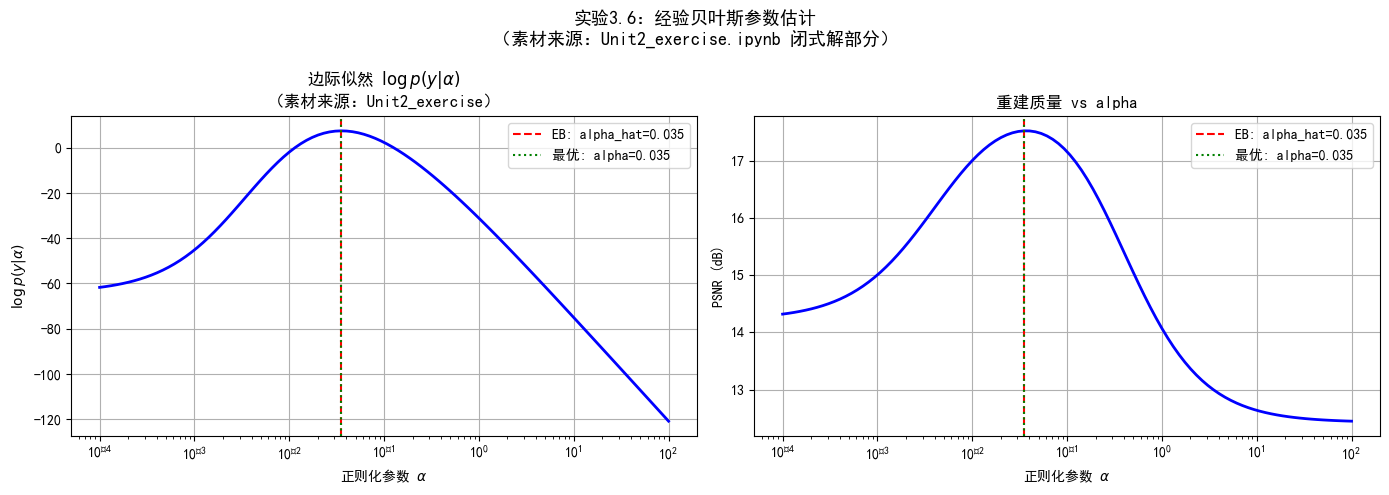

In [1]:
"""
实验3.6 经验贝叶斯参数估计
对应章节：3.6（边际似然最大化、Fisher恒等式、正则化参数自动选择）
素材来源：Mathematics and Machine Learning for image analysis/
          Teaching Unit 6 Final Evaluation/Unit2_exercise.ipynb (高斯共轭闭式解部分)

注：Unit2_exercise.ipynb中的SAPG/MYULA完整实现为stub形式（学生填空），
且依赖外部sampling_tools库，无法直接运行。
此处仅实现高斯共轭情形下边际似然的闭式计算。
SAPG完整实现登记在缺失材料清单中。
"""

import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging

# ====== 解决中文乱码的核心代码 ======
# 1. 彻底屏蔽 matplotlib 的字体警告日志
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 2. 忽略 Python 层面的相关 UserWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")

# 3. 强制使用 ASCII 减号（连字符）替代 Unicode 减号（U+2212），并设置中文字体
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# ========================================================

np.random.seed(42)

# ---- 1. 构造小规模问题（对应Unit2_exercise.ipynb的forward model部分）----
# 原notebook使用blur_operators()构造box blur算子，此处用随机矩阵简化
n = 50   # 信号维度
m = 40   # 观测维度
A = np.random.randn(m, n) / np.sqrt(m)

x_true = np.zeros(n)
x_true[5] = 1.0
x_true[15] = 0.8
x_true[30] = -0.5

sigma2 = 0.01  # 噪声方差（对应Unit2_exercise中的sigma参数）
y = A @ x_true + np.sqrt(sigma2) * np.random.randn(m)

# ---- 2. 边际似然（高斯共轭闭式解）----
def marginal_likelihood(y, A, alpha, sigma2):
    """
    高斯共轭下的边际似然 log p(y|alpha)
    边际协方差: C = sigma^2 * I + alpha * A * A'

    对应Unit2_exercise.ipynb中 "define the likelihood here" 部分
    高斯共轭情形有闭式解，无需MCMC

    原notebook中Fisher恒等式:
        nabla_alpha log p(y|alpha) = E_{p(x|y,alpha)}[nabla_alpha log p(x|alpha)]
    在高斯共轭下可直接计算，无需随机近似
    """
    m = A.shape[0]
    C = sigma2 * np.eye(m) + alpha * A @ A.T
    sign, logdet = np.linalg.slogdet(C)
    C_inv_y = np.linalg.solve(C, y)
    log_ml = -0.5 * m * np.log(2 * np.pi) - 0.5 * logdet - 0.5 * y @ C_inv_y
    return log_ml

# ---- 3. Tikhonov解（用于评估重建质量）----
def tikhonov_solve(y, A, alpha, sigma2):
    return np.linalg.solve(A.T @ A / sigma2 + np.eye(A.shape[1]) / alpha, A.T @ y / sigma2)

# ---- 4. 对比不同参数选择方法 ----
alphas = np.logspace(-4, 2, 100)

# (a) 边际似然（经验贝叶斯）
log_ml = np.array([marginal_likelihood(y, A, alpha, sigma2) for alpha in alphas])
alpha_eb = alphas[np.argmax(log_ml)]

# (b) PSNR（需知真解，仅作参考）
psnrs = []
for alpha in alphas:
    x_hat = tikhonov_solve(y, A, alpha, sigma2)
    mse = np.mean((x_hat - x_true)**2)
    psnrs.append(10 * np.log10(1.0 / mse))
alpha_opt = alphas[np.argmax(psnrs)]

print(f"经验贝叶斯 alpha_hat = {alpha_eb:.4f}")
print(f"真实最优 alpha       = {alpha_opt:.4f}")

# ---- 5. 可视化 ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(alphas, log_ml, 'b-', linewidth=2)
axes[0].axvline(alpha_eb, color='r', linestyle='--', label=f'EB: alpha_hat={alpha_eb:.3f}')
axes[0].axvline(alpha_opt, color='g', linestyle=':', label=f'最优: alpha={alpha_opt:.3f}')
axes[0].set_xlabel('正则化参数 $\\alpha$')
axes[0].set_ylabel('$\\log p(y|\\alpha)$')
axes[0].set_title('边际似然 $\\log p(y|\\alpha)$\n（素材来源：Unit2_exercise）')
axes[0].legend()
axes[0].grid(True)

axes[1].semilogx(alphas, psnrs, 'b-', linewidth=2)
axes[1].axvline(alpha_eb, color='r', linestyle='--', label=f'EB: alpha_hat={alpha_eb:.3f}')
axes[1].axvline(alpha_opt, color='g', linestyle=':', label=f'最优: alpha={alpha_opt:.3f}')
axes[1].set_xlabel('正则化参数 $\\alpha$')
axes[1].set_ylabel('PSNR (dB)')
axes[1].set_title('重建质量 vs alpha')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('实验3.6：经验贝叶斯参数估计\n（素材来源：Unit2_exercise.ipynb 闭式解部分）', fontsize=13)
plt.tight_layout()
plt.show()
